# TFT Test Set Evaluation â€” Zaragoza Solar Forecast

This notebook evaluates the trained TFT model on the held-out test set (2025-07-01 to 2025-12-31).
The test set is touched **exactly once** here. No model selection or hyperparameter decisions are
made in this notebook.

**MLVU evaluation principle:** the test set is a simulation of production deployment. Any information
available during evaluation that wouldn't exist in production constitutes leakage.

**Pipeline steps:**

| # | Step | Purpose |
|---|---|---|
| 0 | Imports & configuration | Libraries, load preprocessing and training params |
| 1 | Reconstruct dataset for test split | Continuous time_idx across all splits |
| 2 | Load model & generate predictions | Best checkpoint from training |
| 3 | Test metrics | RMSE, MAE, RÂ², MASE on original MWh scale |
| 4 | Baseline comparisons | Persistence (24h), climatological (hourly mean) |
| 5 | Visualizations | Time series, scatter, residuals, TFT interpretability |
| 6 | Summary | Final results table |

## Step 0 â€” Imports & configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

import functools
_orig_torch_load = torch.load
@functools.wraps(_orig_torch_load)
def _patched_torch_load(*args, **kwargs):
    if kwargs.get('weights_only') is None:
        kwargs['weights_only'] = False
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# â”€â”€ Paths â”€â”€
DATA_DIR  = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models')

# â”€â”€ Sequence lengths â”€â”€
MAX_ENCODER_LENGTH    = 168
MAX_PREDICTION_LENGTH = 24

# â”€â”€ Feature classification â”€â”€
KNOWN_FUTURE = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
]
OBSERVED = [
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
TARGET = 'pv_generation_mwh'

# â”€â”€ Load params â”€â”€
with open(os.path.join(DATA_DIR, 'preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

with open(os.path.join(MODEL_DIR, 'hp_study_results.json')) as f:
    hp_results = json.load(f)

print(f"Best HPs from training: {hp_results['best_params']}")
print(f"Val metrics: {hp_results['val_metrics_mwh']}")
print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")

Best HPs from training: {'hidden_size': 64, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.30658707681632436, 'hidden_continuous_size': 8, 'learning_rate': 0.0002727138331484171}
Val metrics: {'MAE_MWh': 119.37822723388672, 'RMSE_MWh': 214.51524353027344, 'R2': 0.7824905514717102}
Target denorm: z * 443.4560 + 335.7786


/home/tzf/anaconda3/envs/mlvu/lib/python3.12/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Step 1 â€” Reconstruct dataset for test split

In [2]:
# â”€â”€ Load all three splits â”€â”€
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()

# â”€â”€ Continuous time_idx across all three splits â”€â”€
train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))
test_df['time_idx']  = np.arange(len(train_df) + len(val_df),
                                  len(train_df) + len(val_df) + len(test_df))

train_df['group_id'] = '0'
val_df['group_id']   = '0'
test_df['group_id']  = '0'

print(f"Train: {len(train_df):,} rows  time_idx [0, {train_df['time_idx'].max()}]")
print(f"Val:   {len(val_df):,} rows   time_idx [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")
print(f"Test:  {len(test_df):,} rows  time_idx [{test_df['time_idx'].min()}, {test_df['time_idx'].max()}]")

Train: 17,544 rows  time_idx [0, 17543]
Val:   4,344 rows   time_idx [17544, 21887]
Test:  4,416 rows  time_idx [21888, 26303]


In [3]:
# â”€â”€ Reconstruct training dataset (needed for from_dataset) â”€â”€
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    time_varying_known_reals=KNOWN_FUTURE,
    time_varying_unknown_reals=OBSERVED,
    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE + OBSERVED},
    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

# â”€â”€ Test dataset with encoder context from val tail â”€â”€
# ignore_index=True: val_df.iloc[-168:] has index ~4176-4343 and test_df has
# index 0-4367, making the concat index non-monotonic without it.
# predict=True is intentionally omitted â€” we want full sliding-window evaluation
# (same as val_dataset in training), not just the final prediction window.
test_with_context = pd.concat([
    val_df.iloc[-MAX_ENCODER_LENGTH:],
    test_df
], ignore_index=True)

test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    test_with_context,
    stop_randomization=True,
)

test_dataloader = test_dataset.to_dataloader(
    train=False, batch_size=64, num_workers=2
)

print(f"Test dataset: {len(test_dataset)} samples")
assert len(test_dataset) > 100, \
    f"Test dataset too small ({len(test_dataset)}): check concat/context construction"

Test dataset: 4393 samples


## Step 2 â€” Load model & generate predictions

In [4]:
def denormalize(z_values):
    """Convert z-score normalized values back to original MWh scale."""
    return z_values * TARGET_STD + TARGET_MEAN

def compute_metrics(actual_mwh, predicted_mwh):
    """Compute RMSE, MAE, RÂ² on original MWh scale."""
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2)}

In [5]:
# Load best model checkpoint
ckpt_path = os.path.join(MODEL_DIR, 'tft_best.ckpt')
best_model = TemporalFusionTransformer.load_from_checkpoint(ckpt_path)
best_model.eval()
print(f"Loaded model from {ckpt_path}")
print(f"Model parameters: {sum(p.numel() for p in best_model.parameters()):,}")

Loaded model from /home/tzf/bachelor/MLVU/project/ML-solar-forecast/zaragoza_analysis/models/tft_best.ckpt
Model parameters: 261,323


In [ ]:
# Generate predictions
test_predictions = best_model.predict(
    test_dataloader, mode='prediction', return_x=True, return_y=True,
)
test_raw = best_model.predict(
    test_dataloader, mode='raw', return_x=True
)

# Extract prediction windows (n_windows, 24)
pred_z   = test_predictions.output.cpu().numpy()
actual_z = test_predictions.y[0].cpu().numpy()

# ── Per-timestep aggregation ──
# The TFT produces overlapping 24h windows: window i predicts hours [i, i+23].
# Each test hour gets predicted by up to 24 different windows at different horizons.
# We average all predictions for each timestep to get one prediction per hour,
# ensuring metrics are computed on the same basis as XGBoost (one pred per hour).
n_test = len(test_df)
agg_sum = np.zeros(n_test)
agg_count = np.zeros(n_test)
n_windows = pred_z.shape[0]
for i in range(n_windows):
    for h in range(MAX_PREDICTION_LENGTH):
        t = i + h
        if t < n_test:
            agg_sum[t] += pred_z[i, h]
            agg_count[t] += 1
mask = agg_count > 0
pred_z_agg = np.zeros(n_test)
pred_z_agg[mask] = agg_sum[mask] / agg_count[mask]

pred_mwh   = np.clip(denormalize(pred_z_agg), 0, None)
actual_mwh = denormalize(test_df[TARGET].values)

print(f"Prediction windows: {pred_z.shape[0]}")
print(f"Per-timestep predictions: {mask.sum()} unique test hours")
print(f"  (avg {agg_count[mask].mean():.1f} overlapping windows per hour)")

## Step 3 â€” Test metrics

This is the one and only test set evaluation. No model selection decisions are made after this point.

In [7]:
test_metrics = compute_metrics(actual_mwh, pred_mwh)

# â”€â”€ MASE: Mean Absolute Scaled Error â”€â”€
# Naive baseline: persistence (same hour 24h ago)
test_gen = denormalize(test_df[TARGET].values)
persistence_mae = np.abs(test_gen[24:] - test_gen[:-24]).mean()
mase = test_metrics['MAE_MWh'] / persistence_mae

print("=" * 60)
print("TEST SET METRICS (original MWh scale)")
print("=" * 60)
print(f"  RMSE:  {test_metrics['RMSE_MWh']:.2f} MWh")
print(f"  MAE:   {test_metrics['MAE_MWh']:.2f} MWh")
print(f"  RÂ²:    {test_metrics['R2']:.4f}")
print(f"  MASE:  {mase:.4f} (< 1 means TFT beats 24h persistence)")
print("=" * 60)

TEST SET METRICS (original MWh scale)
  RMSE:  195.87 MWh
  MAE:   104.60 MWh
  RÂ²:    0.8464
  MASE:  0.8998 (< 1 means TFT beats 24h persistence)


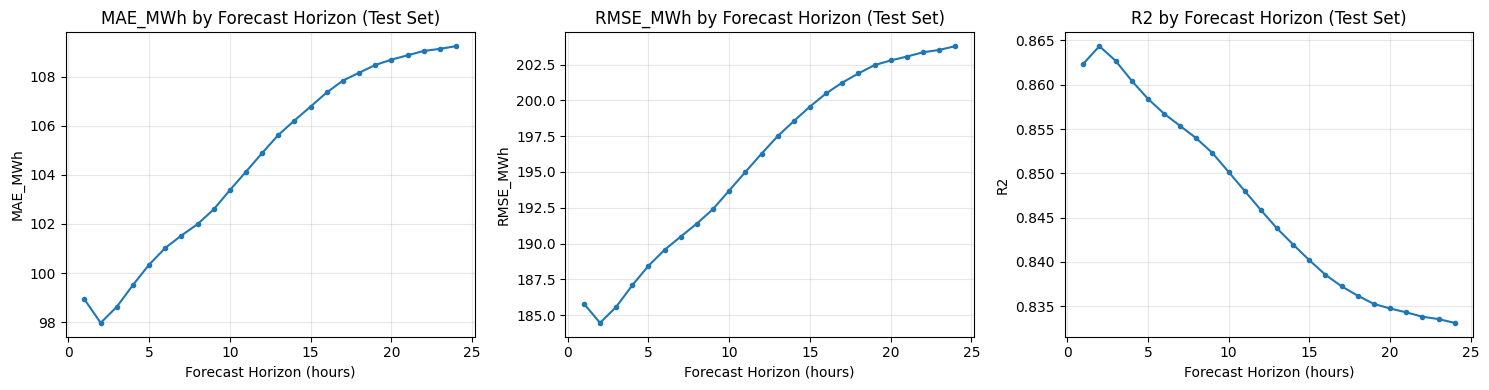

   MAE_MWh   RMSE_MWh       R2  horizon_h
 98.925560 185.808319 0.862355          1
 97.967850 184.459381 0.864347          2
 98.622688 185.574188 0.862702          3
 99.511368 187.088577 0.860452          4
100.340225 188.447327 0.858418          5
101.019264 189.560944 0.856739          6
101.526917 190.489227 0.855349          7
101.992004 191.393890 0.853959          8
102.592674 192.411835 0.852286          9
103.375282 193.703979 0.850163         10
104.128090 194.995285 0.848010         11
104.887703 196.273254 0.845856         12
105.622581 197.496140 0.843781         13
106.213249 198.551788 0.841960         14
106.781509 199.564011 0.840196         15
107.354942 200.487213 0.838551         16
107.840599 201.237885 0.837247         17
108.157463 201.879440 0.836192         18
108.474403 202.462189 0.835262         19
108.692719 202.786301 0.834751         20
108.869057 203.058121 0.834310         21
109.046265 203.355759 0.833824         22
109.132347 203.520187 0.833555    

In [8]:
# â”€â”€ Per-horizon metrics â”€â”€
horizon_metrics = []
for h in range(MAX_PREDICTION_LENGTH):
    pred_h   = np.clip(denormalize(pred_z[:, h]), 0, None)
    actual_h = denormalize(actual_z[:, h])
    m = compute_metrics(actual_h, pred_h)
    m['horizon_h'] = h + 1
    horizon_metrics.append(m)

horizon_df = pd.DataFrame(horizon_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE_MWh', 'RMSE_MWh', 'R2']):
    ax.plot(horizon_df['horizon_h'], horizon_df[metric], marker='o', markersize=3)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Forecast Horizon (Test Set)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(horizon_df.to_string(index=False))

## Step 4 â€” Baseline comparisons

Compare the TFT against two simple baselines:

- **Persistence (24h):** predict the same hour from 24 hours ago
- **Climatological (hourly):** predict the average generation for each hour-of-day from the training set

In [9]:
# â”€â”€ Persistence baseline: same hour 24h ago â”€â”€
test_gen = denormalize(test_df[TARGET].values)
persistence_pred   = test_gen[:-24]
persistence_actual = test_gen[24:]
persistence_metrics = compute_metrics(persistence_actual, persistence_pred)

# â”€â”€ Climatological baseline: hourly mean from training set â”€â”€
train_gen_mwh = denormalize(train_df[TARGET].values)
train_hours   = pd.to_datetime(train_df['datetime_utc']).dt.hour
hourly_means  = pd.Series(train_gen_mwh, index=train_hours.values).groupby(level=0).mean()

test_hours = pd.to_datetime(test_df['datetime_utc']).dt.hour.values
clim_pred  = hourly_means.loc[test_hours].values
clim_actual = test_gen
clim_metrics = compute_metrics(clim_actual, clim_pred)

# â”€â”€ Comparison table â”€â”€
print(f"\n{'Model':<25s} {'RMSE (MWh)':>12s} {'MAE (MWh)':>12s} {'RÂ²':>8s}")
print("-" * 60)
print(f"{'TFT (ours)':<25s} {test_metrics['RMSE_MWh']:12.2f} {test_metrics['MAE_MWh']:12.2f} {test_metrics['R2']:8.4f}")
print(f"{'Persistence (24h)':<25s} {persistence_metrics['RMSE_MWh']:12.2f} {persistence_metrics['MAE_MWh']:12.2f} {persistence_metrics['R2']:8.4f}")
print(f"{'Climatological (hourly)':<25s} {clim_metrics['RMSE_MWh']:12.2f} {clim_metrics['MAE_MWh']:12.2f} {clim_metrics['R2']:8.4f}")


Model                       RMSE (MWh)    MAE (MWh)       RÂ²
------------------------------------------------------------
TFT (ours)                      195.87       104.60   0.8464
Persistence (24h)               236.37       116.24   0.7755
Climatological (hourly)         279.57       173.41   0.6878


## Step 5 â€” Visualizations

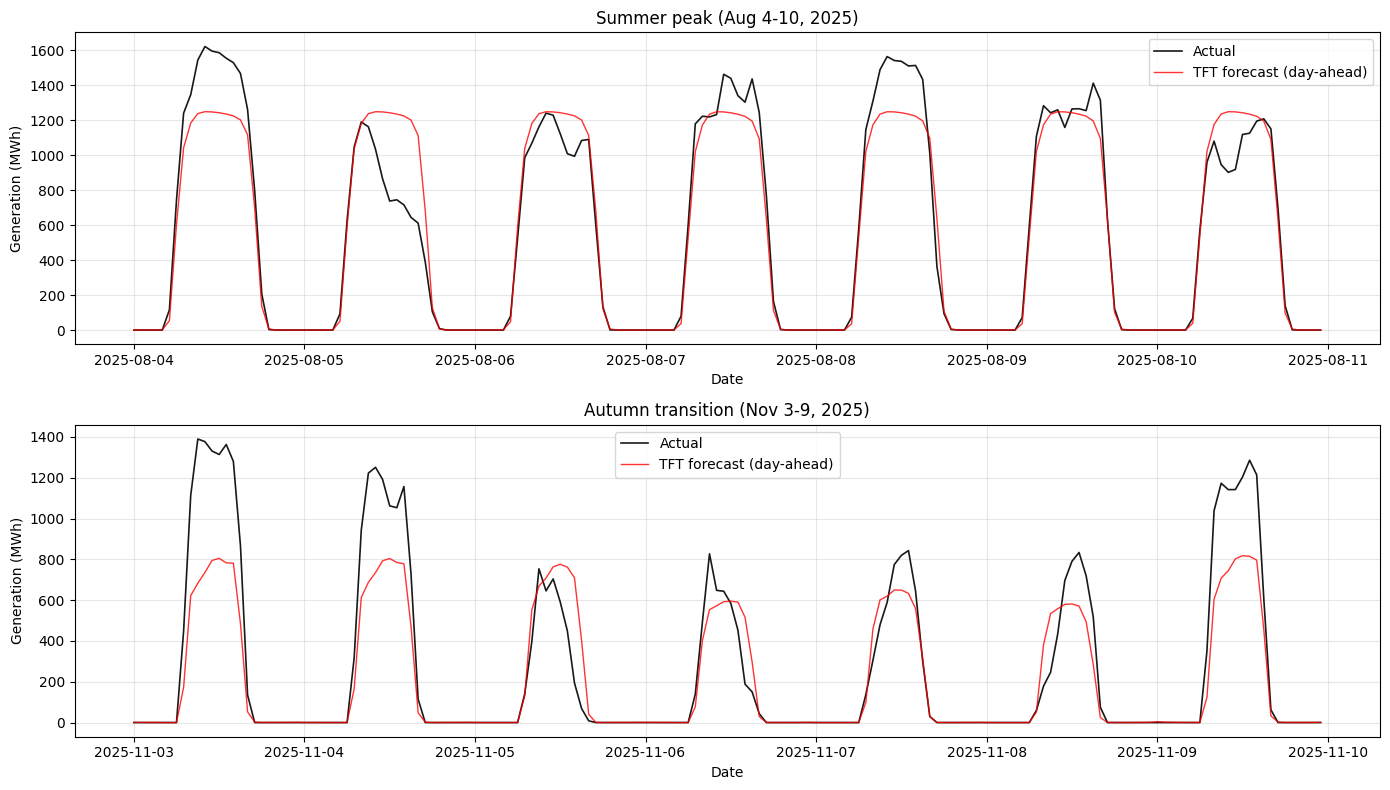

In [10]:
# â”€â”€ 5a: Time series â€” selected test weeks â”€â”€
# Build day-ahead forecast series by taking the window that starts at 00:00
# each day and using its full 24h prediction. This mirrors real deployment:
# one forecast run per day covering the next 24 hours.
test_datetime = pd.to_datetime(test_df['datetime_utc'])
n_windows = pred_z.shape[0]

dayahead_pred   = {}
dayahead_actual = {}
for i in range(n_windows):
    ts = test_datetime.iloc[i]
    if ts.hour == 0:
        for h in range(MAX_PREDICTION_LENGTH):
            idx = i + h
            if idx < len(test_df):
                t = test_datetime.iloc[idx]
                dayahead_pred[t]   = np.clip(denormalize(pred_z[i, h]), 0, None)
                dayahead_actual[t] = denormalize(test_df[TARGET].iloc[idx])

pred_dayahead_series   = pd.Series(dayahead_pred)
actual_dayahead_series = pd.Series(dayahead_actual)

week_starts = [
    ('Summer peak (Aug 4-10, 2025)', '2025-08-04', '2025-08-10'),
    ('Autumn transition (Nov 3-9, 2025)', '2025-11-03', '2025-11-09'),
]

fig, axes = plt.subplots(len(week_starts), 1, figsize=(14, 4 * len(week_starts)))
if len(week_starts) == 1:
    axes = [axes]

for ax, (title, start, end) in zip(axes, week_starts):
    end_ts = end + ' 23:00:00'
    actual_week = actual_dayahead_series[start:end_ts]
    pred_week   = pred_dayahead_series[start:end_ts]
    ax.plot(actual_week.index, actual_week.values, 'k-', linewidth=1.2, label='Actual', alpha=0.9)
    ax.plot(pred_week.index,   pred_week.values,   'r-', linewidth=1.0, label='TFT forecast (day-ahead)', alpha=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Generation (MWh)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

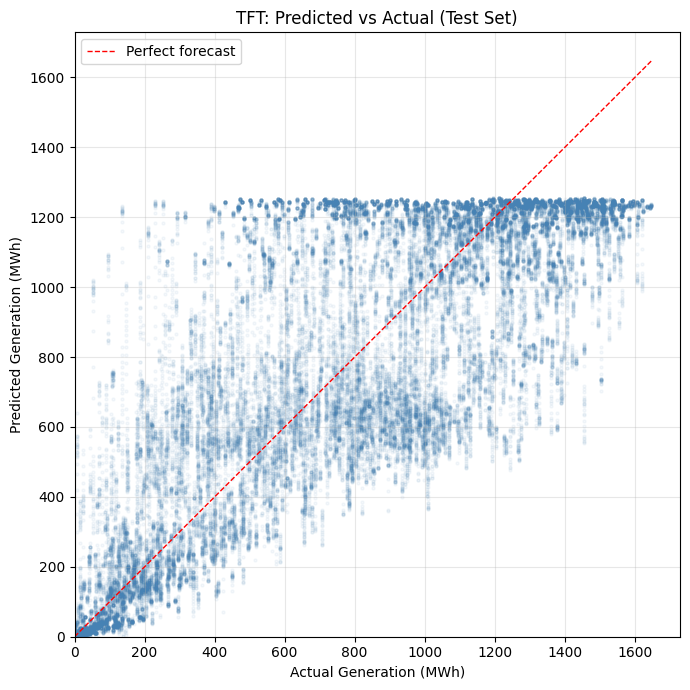

In [11]:
# â”€â”€ 5b: Scatter plot â€” predicted vs actual â”€â”€
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual_mwh, pred_mwh, alpha=0.05, s=5, c='steelblue')
max_val = max(actual_mwh.max(), pred_mwh.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual Generation (MWh)')
ax.set_ylabel('Predicted Generation (MWh)')
ax.set_title('TFT: Predicted vs Actual (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)
plt.tight_layout()
plt.show()

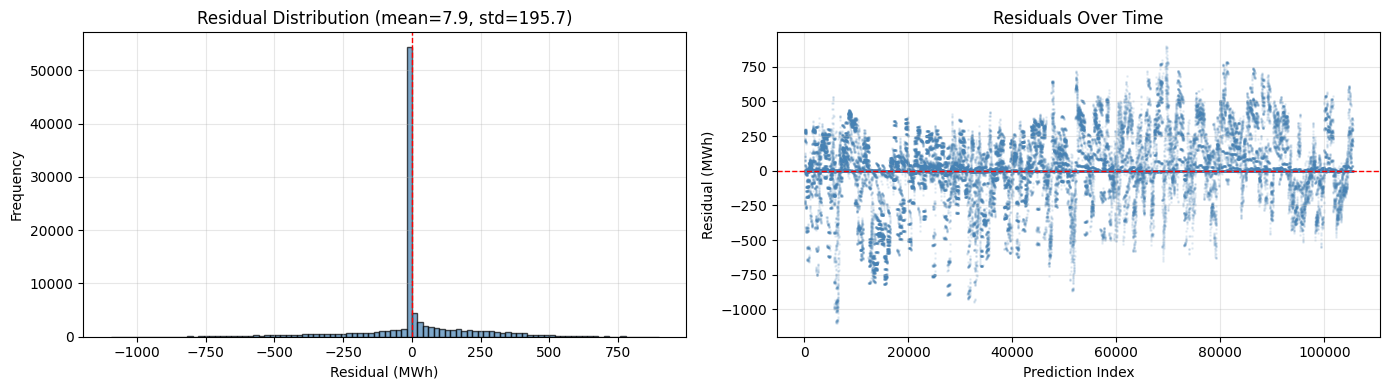

In [12]:
# â”€â”€ 5c: Residual analysis â”€â”€
residuals = actual_mwh - pred_mwh

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Residual (MWh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Residual Distribution (mean={residuals.mean():.1f}, std={residuals.std():.1f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(np.arange(len(residuals)), residuals, s=1, alpha=0.1, c='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Prediction Index')
axes[1].set_ylabel('Residual (MWh)')
axes[1].set_title('Residuals Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

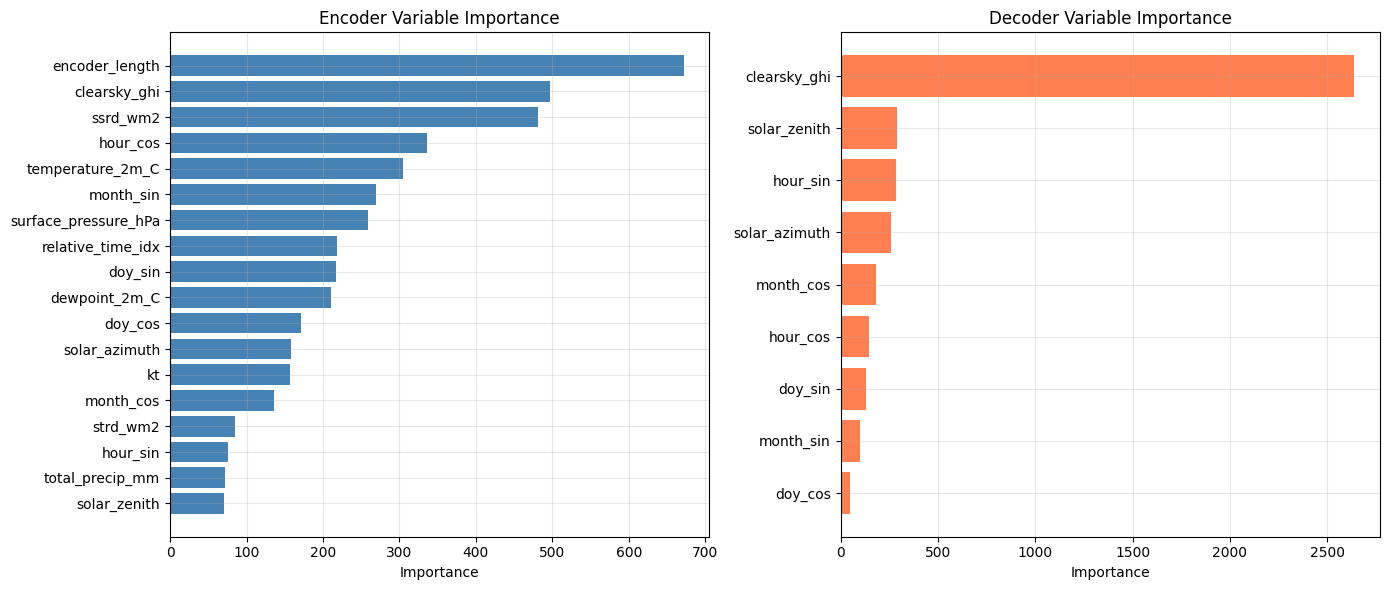

In [13]:
# â”€â”€ 5d: TFT interpretability â€” variable importance â”€â”€
interpretation = best_model.interpret_output(test_raw.output, reduction='sum')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Encoder variable importance â€” all real-valued encoder inputs
enc_vars = training_dataset.reals
enc_imp  = interpretation['encoder_variables'].cpu().numpy()
enc_sorted = sorted(zip(enc_vars, enc_imp), key=lambda x: x[1], reverse=True)
enc_names, enc_vals = zip(*enc_sorted)
axes[0].barh(range(len(enc_names)), enc_vals, color='steelblue')
axes[0].set_yticks(range(len(enc_names)))
axes[0].set_yticklabels(enc_names)
axes[0].set_xlabel('Importance')
axes[0].set_title('Encoder Variable Importance')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# Decoder variable importance â€” only known-future variables (visible at prediction time)
dec_vars = list(training_dataset.time_varying_known_reals)
dec_imp  = interpretation['decoder_variables'].cpu().numpy()
dec_sorted = sorted(zip(dec_vars, dec_imp), key=lambda x: x[1], reverse=True)
dec_names, dec_vals = zip(*dec_sorted)
axes[1].barh(range(len(dec_names)), dec_vals, color='coral')
axes[1].set_yticks(range(len(dec_names)))
axes[1].set_yticklabels(dec_names)
axes[1].set_xlabel('Importance')
axes[1].set_title('Decoder Variable Importance')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

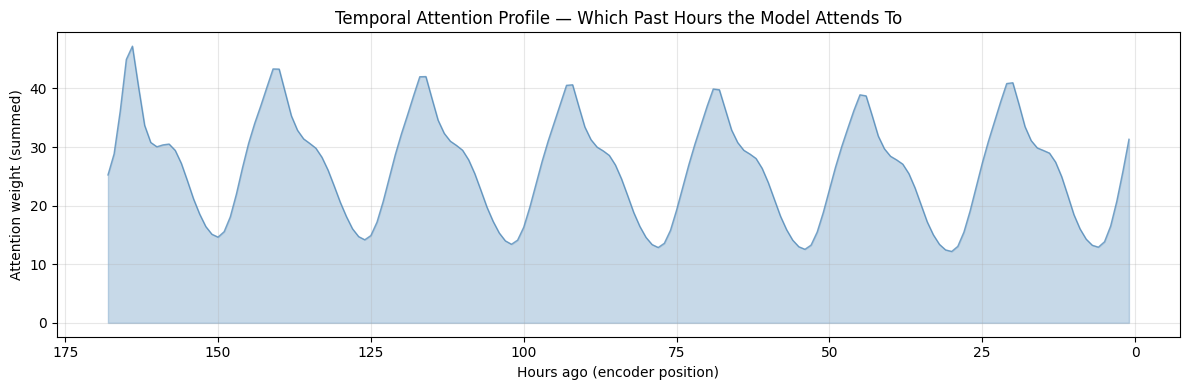

Attention shape: (168,)
Peak attention at 164h ago


In [14]:
# â”€â”€ 5e: Temporal attention pattern â”€â”€
attention = interpretation['attention'].cpu().numpy()  # (encoder_length,) after reduction='sum'

fig, ax = plt.subplots(figsize=(12, 4))
hours_ago = np.arange(MAX_ENCODER_LENGTH, 0, -1)
ax.plot(hours_ago, attention, linewidth=1, color='steelblue', alpha=0.7)
ax.fill_between(hours_ago, attention, alpha=0.3, color='steelblue')
ax.invert_xaxis()
ax.set_xlabel('Hours ago (encoder position)')
ax.set_ylabel('Attention weight (summed)')
ax.set_title('Temporal Attention Profile â€” Which Past Hours the Model Attends To')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Attention shape: {attention.shape}")
print(f"Peak attention at {hours_ago[attention.argmax()]}h ago")


## Step 6 â€” Summary

In [15]:
print("=" * 70)
print("FINAL TEST RESULTS â€” Zaragoza TFT Solar Forecast")
print("=" * 70)

print(f"\nModel: Temporal Fusion Transformer")
print(f"Test period: 2025-07-01 to 2025-12-31")
print(f"Encoder length: {MAX_ENCODER_LENGTH}h ({MAX_ENCODER_LENGTH//24} days)")
print(f"Prediction length: {MAX_PREDICTION_LENGTH}h (day-ahead)")

print(f"\nHyperparameters (selected via Optuna, {hp_results['n_trials']} trials):")
for k, v in hp_results['best_params'].items():
    print(f"  {k}: {v}")

print(f"\n{'Metric':<15s} {'Validation':>12s} {'Test':>12s}")
print("-" * 42)
for metric in ['RMSE_MWh', 'MAE_MWh', 'R2']:
    val_v  = hp_results['val_metrics_mwh'][metric]
    test_v = test_metrics[metric]
    fmt = '.2f' if 'MWh' in metric else '.4f'
    print(f"{metric:<15s} {val_v:12{fmt}} {test_v:12{fmt}}")
print(f"{'MASE':<15s} {'â€”':>12s} {mase:12.4f}")

print(f"\nBaseline comparison (test set):")
print(f"  TFT RÂ²:          {test_metrics['R2']:.4f}")
print(f"  Persistence RÂ²:  {persistence_metrics['R2']:.4f}")
print(f"  Climatology RÂ²:  {clim_metrics['R2']:.4f}")

print(f"\nMASE = {mase:.4f} â†’ {'TFT outperforms persistence' if mase < 1 else 'Persistence is competitive'}")
print("=" * 70)

FINAL TEST RESULTS â€” Zaragoza TFT Solar Forecast

Model: Temporal Fusion Transformer
Test period: 2025-07-01 to 2025-12-31
Encoder length: 168h (7 days)
Prediction length: 24h (day-ahead)

Hyperparameters (selected via Optuna, 15 trials):
  hidden_size: 64
  lstm_layers: 1
  attention_head_size: 4
  dropout: 0.30658707681632436
  hidden_continuous_size: 8
  learning_rate: 0.0002727138331484171

Metric            Validation         Test
------------------------------------------
RMSE_MWh              214.52       195.87
MAE_MWh               119.38       104.60
R2                    0.7825       0.8464
MASE                       â€”       0.8998

Baseline comparison (test set):
  TFT RÂ²:          0.8464
  Persistence RÂ²:  0.7755
  Climatology RÂ²:  0.6878

MASE = 0.8998 â†’ TFT outperforms persistence


In [ ]:
# Save test metrics back to hp_study_results.json
json_path = os.path.join(MODEL_DIR, 'hp_study_results.json')
with open(json_path) as f:
    data = json.load(f)
data['test_metrics_mwh'] = {
    'MAE_MWh':  test_metrics['MAE_MWh'],
    'RMSE_MWh': test_metrics['RMSE_MWh'],
    'R2':       test_metrics['R2'],
}
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)
print(f'Saved test_metrics_mwh to {json_path}')